## Kaggle BT4012
Student ID: E0957731

## Load Dataset for visualisation


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
train_df = pd.read_csv('./datasets/train.csv')
test_df = pd.read_csv('./datasets/test.csv')
sample_submission_df = pd.read_csv('./datasets/sample_submission.csv')

train_df = train_df.copy()
test_df = test_df.copy()
sample_submission_df = sample_submission_df.copy()

# Display the first few rows of the training dataset to understand its structure
train_df.head()

FileNotFoundError: [Errno 2] No such file or directory: './train.csv'

## Check for duplicated rows
- No duplicated rows were found

In [ ]:
duplicates = train_df.duplicated()
num_duplicates = duplicates.sum()

print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 0


## Check for imbalanced dataset
- Data is slightly imbalanced but not at a problematic level (XGBoost likely covers for it)

Target Distribution:
 target
0    0.664848
1    0.335152
Name: proportion, dtype: float64


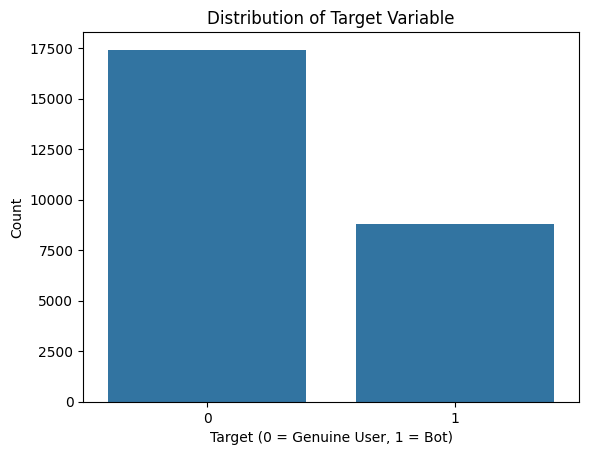

In [ ]:
# Check the distribution of the target variable
target_counts = train_df['target'].value_counts(normalize=True)
print("Target Distribution:\n", target_counts)

# Visualize the distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=train_df, x='target')
plt.title("Distribution of Target Variable")
plt.xlabel("Target (0 = Genuine User, 1 = Bot)")
plt.ylabel("Count")
plt.show()


## Handle missing data

Upon inspecting the dataset, there are several fields with null values. Since these fields are all categorical, I decided to fill the missing values with the appropriate categorical values:

- Missing values filled with **"Unknown"**: Used for columns like `description`,`lang`,`location` where missing data likely means the information is unavailable or not applicable. This preserves the understanding that the data may exist but is not provided.

In [ ]:
# Check for missing values in the training dataset
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Missing values summary:", missing_values)

# Impute missing values
train_df['description'] = train_df['description'].fillna('unknown')
train_df['lang'] = train_df['lang'].fillna('unknown')
train_df['location'] = train_df['location'].fillna('unknown')
train_df['profile_background_image_url'] = train_df['location'].fillna('unknown')
train_df['profile_image_url'] = train_df['location'].fillna('unknown')


test_df['description'] = test_df['description'].fillna('unknown')
test_df['lang'] = test_df['lang'].fillna('unknown')
test_df['location'] = test_df['location'].fillna('unknown')
train_df['profile_background_image_url'] = train_df['location'].fillna('unknown')
train_df['profile_image_url'] = train_df['location'].fillna('unknown')


Missing values summary: description                     5091
lang                            5588
location                           2
profile_background_image_url    3235
profile_image_url                  1
dtype: int64


## Check for any missing data

In [ ]:
# Verify there are no missing values left
assert train_df.isnull().sum().sum() == 0, "There are still missing values"

## Feature Engineering

### Consider
    - Engagement Ratios
    - Normalized Activity Rates
    - Composite Indicators
    - Account age categories
    - Boolean features and profile completeness
    - Social Activity Rates
    - Text based features
    - Tweet patterns
    - Description and Screen Name Patterns
    - Advanced Engagement Metrics
    - Boolean Flags for Account Characteristics
    - Temporal Patterns
    - Textual Features
    - Suspicious Behaviour Flags

### Other insights to consider    
    - verified to target to check if being verified has any correlation to being a bot account
    - account_age_days to target to check if age of account has any correlation to being a bot account
    - geo_enabled to target to check if there is a correlation between enabling location services and bot accounts

In [ ]:
# LOG BASED FIX
# =========================
# Log-transformed ratio-style features
# =========================

# Engagement Ratios -> convert to log-ratio form
train_df['log_followers_friends_ratio'] = (
    np.log1p(train_df['followers_count']) - np.log1p(train_df['friends_count'])
)

train_df['log_statuses_followers_ratio'] = (
    np.log1p(train_df['statuses_count']) - np.log1p(train_df['followers_count'])
)

train_df['log_favourites_followers_ratio'] = (
    np.log1p(train_df['favourites_count']) - np.log1p(train_df['followers_count'])
)

# Normalized Activity Rates -> convert to log(count per age) style
train_df['log_normalized_followers'] = (
    np.log1p(train_df['followers_count']) - np.log1p(train_df['account_age_days'])
)

train_df['log_normalized_friends'] = (
    np.log1p(train_df['friends_count']) - np.log1p(train_df['account_age_days'])
)

train_df['log_normalized_statuses'] = (
    np.log1p(train_df['statuses_count']) - np.log1p(train_df['account_age_days'])
)

train_df['log_normalized_favourites'] = (
    np.log1p(train_df['favourites_count']) - np.log1p(train_df['account_age_days'])
)

# Social Activity Ratios
train_df['log_tweets_per_friends'] = (
    np.log1p(train_df['statuses_count']) - np.log1p(train_df['friends_count'])
)

train_df['log_likes_per_tweet'] = (
    np.log1p(train_df['favourites_count']) - np.log1p(train_df['statuses_count'])
)

train_df['log_tweet_to_follower_ratio'] = (
    np.log1p(train_df['statuses_count']) - np.log1p(train_df['followers_count'])
)

# Tweet pattern rate
train_df['log_tweets_per_day_relative_to_age'] = (
    np.log1p(train_df['average_tweets_per_day']) - np.log1p(train_df['account_age_days'])
)

# Advanced engagement metric
train_df['log_likes_engagement_ratio'] = (
    np.log1p(train_df['favourites_count']) - 
    np.log1p(train_df['followers_count'] + train_df['friends_count'])
)

# =========================
# Features that should remain as-is
# =========================

# Composite Indicators
high_activity_threshold = train_df['average_tweets_per_day'].quantile(0.90)
train_df['high_activity_low_engagement'] = (
    (train_df['average_tweets_per_day'] > high_activity_threshold) & 
    (train_df['followers_count'] < 100)
).astype(int)

tweet_frequency_threshold = train_df['average_tweets_per_day'].quantile(0.90)
account_age_threshold = 365

train_df['high_tweet_low_age'] = (
    (train_df['average_tweets_per_day'] > tweet_frequency_threshold) & 
    (train_df['account_age_days'] < account_age_threshold)
).astype(int)

# Account Age Categories
train_df['account_age_category'] = pd.cut(
    train_df['account_age_days'],
    bins=[0, 365, 730, 1825, float('inf')],
    labels=["Very New", "New", "Established", "Old"]
).cat.codes

# Boolean Features and Profile Completeness
train_df['has_profile_image'] = (train_df['profile_image_url'] != 'unknown').astype(int)
train_df['has_background_image'] = (train_df['profile_background_image_url'] != 'unknown').astype(int)

# Text-Based Features
train_df['description_length'] = train_df['description'].apply(lambda x: len(x))
train_df['username_length'] = train_df['screen_name'].apply(lambda x: len(x))
train_df['description_word_count'] = train_df['description'].apply(lambda x: len(x.split()))
train_df['has_url_in_description'] = train_df['description'].apply(
    lambda x: int('http' in x or 'www' in x)
)

# FE part 2

# Description and Screen Name Patterns
train_df['screen_name_digit_ratio'] = train_df['screen_name'].apply(
    lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0
)

train_df['description_digit_ratio'] = train_df['description'].apply(
    lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0
)

train_df['description_special_chars_count'] = train_df['description'].apply(
    lambda x: sum(1 for c in x if c in '!@#$%^&*') if isinstance(x, str) else 0
)

# Advanced Engagement Metrics
train_df['follower_friend_disparity'] = abs(
    train_df['followers_count'] - train_df['friends_count']
)

# Boolean Flags for Account Characteristics
followers_threshold = train_df['followers_count'].quantile(0.10)
tweets_threshold = train_df['average_tweets_per_day'].quantile(0.90)
train_df['is_low_follower_high_activity'] = (
    (train_df['followers_count'] < followers_threshold) & 
    (train_df['average_tweets_per_day'] > tweets_threshold)
).astype(int)

statuses_threshold = train_df['statuses_count'].quantile(0.90)
engagement_threshold = train_df['favourites_count'].quantile(0.10)
train_df['is_high_status_low_engagement'] = (
    (train_df['statuses_count'] > statuses_threshold) & 
    (train_df['favourites_count'] < engagement_threshold)
).astype(int)

# Temporal Patterns
train_df['is_new_with_verified'] = (
    (train_df['account_age_days'] < 365) & (train_df['verified'] == 1)
).astype(int)

train_df['is_recently_active_high_activity'] = (
    (train_df['account_age_days'] < 90) & (train_df['statuses_count'] > 500)
).astype(int)

# Textual Features
train_df['description_uppercase_ratio'] = train_df['description'].apply(
    lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0
)

train_df['username_special_chars_ratio'] = train_df['screen_name'].apply(
    lambda x: sum(1 for c in x if not c.isalnum()) / len(x) if len(x) > 0 else 0
)

# Suspicious Behavior Flags
train_df['has_profile_links'] = train_df.apply(
    lambda x: int('http' in str(x['description']) or 'http' in str(x['profile_background_image_url'])),
    axis=1
)

# Spam words
spam_words = [
    'win', 'free', 'offer', 'click', 'buy', 'subscribe', 
    'act now', 'apply now', 'call now', 'don’t hesitate', 
    'for only', 'get started now', 'limited time', 'great offer', 
    'instant', 'now only', 'offer expires', 'once in a lifetime', 
    'order now', 'order today', 'special promotion', 'urgent', 
    'while supplies last', 'bonus', 'all new', 'amazing', 
    'certified', 'congratulations', 'fantastic deal', 'for free', 
    'guaranteed', 'outstanding value', 'risk free', 
    'satisfaction guaranteed', 'free!', 'free trial', 'free consultation', 
    'free gift', 'free membership', 'free offer', 'free preview', 
    'free sample', 'free quote', 'sign up free today', 'deal', 
    'giving away', 'no obligation', 'no strings attached', 'offer', 
    'prize', 'trial', 'unlimited', 'what are you waiting for?', 
    'win', 'winner', 'you’re a winner!', 'won', 'you have been selected', 
    '#1', '100% free', '100% satisfied', '50% off', 
    'one hundred percent guaranteed', 'click below', 'click here', 
    'increase sales', 'increase your sales', 'opt in', 'open', 'sale', 
    'sales', 'subscribe', 'chance', 'sample', 'satisfaction', 'solution', 
    'success', 'cards accepted', 'full refund', 'affordable', 
    'bargain', 'best price', 'cash', 'cash bonus', 'cheap', 
    'credit', 'discount', 'for just $', 'lowest price', 'save big money', 
    'why pay more?', 'buy', 'as seen on', 'buy direct', 'clearance', 
    'order', '$$$', 'marketing solutions', 'join millions', 
    'name brand', 'no questions asked', 'giving it away', 
    'best rates', 'compare', 'drastically reduced'
]

train_df['description_spam_score'] = train_df['description'].apply(
    lambda x: sum(word in x.lower() for word in spam_words) if isinstance(x, str) else 0
)

In [ ]:
# # Engagement Ratios
# train_df['followers_friends_ratio'] = train_df['followers_count'] / (train_df['friends_count'] + 1e-5)
# train_df['statuses_followers_ratio'] = train_df['statuses_count'] / (train_df['followers_count'] + 1e-5)
# train_df['favourites_followers_ratio'] = train_df['favourites_count'] / (train_df['followers_count'] + 1e-5)

# # Normalized Activity Rates
# train_df['normalized_followers'] = train_df['followers_count'] / (train_df['account_age_days'] + 1e-5)
# train_df['normalized_friends'] = train_df['friends_count'] / (train_df['account_age_days'] + 1e-5)
# train_df['normalized_statuses'] = train_df['statuses_count'] / (train_df['account_age_days'] + 1e-5)
# train_df['normalized_favourites'] = train_df['favourites_count'] / (train_df['account_age_days'] + 1e-5)

# # Composite Indicators
# high_activity_threshold = train_df['average_tweets_per_day'].quantile(0.90)
# train_df['high_activity_low_engagement'] = ((train_df['average_tweets_per_day'] > high_activity_threshold) & 
#                                             (train_df['followers_count'] < 100)).astype(int)

# # Define thresholds based on quantiles
# tweet_frequency_threshold = train_df['average_tweets_per_day'].quantile(0.90)  # 90th percentile for high tweets
# account_age_threshold = 365  # 1 year (365 days) as the threshold for low account age

# # Create a composite feature that flags accounts with high tweet frequency and low account age
# train_df['high_tweet_low_age'] = ((train_df['average_tweets_per_day'] > tweet_frequency_threshold) & 
#                                   (train_df['account_age_days'] < account_age_threshold)).astype(int)


# # Account Age Categories
# train_df['account_age_category'] = pd.cut(
#     train_df['account_age_days'],
#     bins=[0, 365, 730, 1825, float('inf')],
#     labels=["Very New", "New", "Established", "Old"]
# ).cat.codes

# # Boolean Features and Profile Completeness
# train_df['has_profile_image'] = (train_df['profile_image_url'] != 'unknown').astype(int)
# train_df['has_background_image'] = (train_df['profile_background_image_url'] != 'unknown').astype(int)

# # Social Activity Ratios
# train_df['tweets_per_friends'] = train_df['statuses_count'] / (train_df['friends_count'] + 1e-5)
# train_df['likes_per_tweet'] = train_df['favourites_count'] / (train_df['statuses_count'] + 1e-5)
# train_df["tweet_to_follower_ratio"] = train_df["statuses_count"] / (train_df["followers_count"] + 1)

# # Text-Based Features
# train_df['description_length'] = train_df['description'].apply(lambda x: len(x))
# train_df['username_length'] = train_df['screen_name'].apply(lambda x: len(x))
# train_df['description_word_count'] = train_df['description'].apply(lambda x: len(x.split()))
# train_df['has_url_in_description'] = train_df['description'].apply(lambda x: int('http' in x or 'www' in x))

# # Tweet Patterns
# train_df['tweets_per_day_relative_to_age'] = train_df['average_tweets_per_day'] / (train_df['account_age_days'] + 1e-5)

# ## train_df['early_activity_intensity'] = train_df['statuses_count'] / (train_df['account_age_days'] + 1e-5)

# #FE part 2#

# # Description and Screen Name Patterns
# train_df['screen_name_digit_ratio'] = train_df['screen_name'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)
# train_df['description_digit_ratio'] = train_df['description'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)
# train_df['description_special_chars_count'] = train_df['description'].apply(lambda x: sum(1 for c in x if c in '!@#$%^&*') if isinstance(x, str) else 0)

# # Advanced Engagement Metrics
# train_df['follower_friend_disparity'] = abs(train_df['followers_count'] - train_df['friends_count'])
# train_df['likes_engagement_ratio'] = train_df['favourites_count'] / (train_df['followers_count'] + train_df['friends_count'] + 1e-5)

# # Boolean Flags for Account Characteristics
# followers_threshold = train_df['followers_count'].quantile(0.10)
# tweets_threshold = train_df['average_tweets_per_day'].quantile(0.90)
# train_df['is_low_follower_high_activity'] = ((train_df['followers_count'] < followers_threshold) & 
#                                              (train_df['average_tweets_per_day'] > tweets_threshold)).astype(int)

# statuses_threshold = train_df['statuses_count'].quantile(0.90)
# engagement_threshold = train_df['favourites_count'].quantile(0.10)
# train_df['is_high_status_low_engagement'] = ((train_df['statuses_count'] > statuses_threshold) & 
#                                              (train_df['favourites_count'] < engagement_threshold)).astype(int)

# # Temporal Patterns
# train_df['is_new_with_verified'] = ((train_df['account_age_days'] < 365) & (train_df['verified'] == 1)).astype(int)
# train_df['is_recently_active_high_activity'] = ((train_df['account_age_days'] < 90) & (train_df['statuses_count'] > 500)).astype(int)

# # Textual Features
# train_df['description_uppercase_ratio'] = train_df['description'].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)
# train_df['username_special_chars_ratio'] = train_df['screen_name'].apply(lambda x: sum(1 for c in x if not c.isalnum()) / len(x) if len(x) > 0 else 0)

# # Suspicious Behavior Flags
# train_df['has_profile_links'] = train_df.apply(lambda x: int('http' in str(x['description']) or 'http' in str(x['profile_background_image_url'])), axis=1)

# # some words referenced from https://lix-it.com/blog/spam-trigger-words/#spam
# spam_words = [
#     'win', 'free', 'offer', 'click', 'buy', 'subscribe', 
#     'act now', 'apply now', 'call now', 'don’t hesitate', 
#     'for only', 'get started now', 'limited time', 'great offer', 
#     'instant', 'now only', 'offer expires', 'once in a lifetime', 
#     'order now', 'order today', 'special promotion', 'urgent', 
#     'while supplies last', 'bonus', 'all new', 'amazing', 
#     'certified', 'congratulations', 'fantastic deal', 'for free', 
#     'guaranteed', 'outstanding value', 'risk free', 
#     'satisfaction guaranteed', 'free!', 'free trial', 'free consultation', 
#     'free gift', 'free membership', 'free offer', 'free preview', 
#     'free sample', 'free quote', 'sign up free today', 'deal', 
#     'giving away', 'no obligation', 'no strings attached', 'offer', 
#     'prize', 'trial', 'unlimited', 'what are you waiting for?', 
#     'win', 'winner', 'you’re a winner!', 'won', 'you have been selected', 
#     '#1', '100% free', '100% satisfied', '50% off', 
#     'one hundred percent guaranteed', 'click below', 'click here', 
#     'increase sales', 'increase your sales', 'opt in', 'open', 'sale', 
#     'sales', 'subscribe', 'chance', 'sample', 'satisfaction', 'solution', 
#     'success', 'cards accepted', 'full refund', 'affordable', 
#     'bargain', 'best price', 'cash', 'cash bonus', 'cheap', 
#     'credit', 'discount', 'for just $', 'lowest price', 'save big money', 
#     'why pay more?', 'buy', 'as seen on', 'buy direct', 'clearance', 
#     'order', '$$$', 'marketing solutions', 'join millions', 
#     'name brand', 'no questions asked', 'giving it away', 
#     'best rates', 'compare', 'drastically reduced'
# ]

# # Update spam score feature using the spam words list
# train_df['description_spam_score'] = train_df['description'].apply(
#     lambda x: sum(word in x.lower() for word in spam_words) if isinstance(x, str) else 0
# )



**Test dataset label copying**


In [ ]:
# # Engagement Ratios
# test_df['followers_friends_ratio'] = test_df['followers_count'] / (test_df['friends_count'] + 1e-5)
# test_df['statuses_followers_ratio'] = test_df['statuses_count'] / (test_df['followers_count'] + 1e-5)
# test_df['favourites_followers_ratio'] = test_df['favourites_count'] / (test_df['followers_count'] + 1e-5)

# # Normalized Activity Rates
# test_df['normalized_followers'] = test_df['followers_count'] / (test_df['account_age_days'] + 1e-5)
# test_df['normalized_friends'] = test_df['friends_count'] / (test_df['account_age_days'] + 1e-5)
# test_df['normalized_statuses'] = test_df['statuses_count'] / (test_df['account_age_days'] + 1e-5)
# test_df['normalized_favourites'] = test_df['favourites_count'] / (test_df['account_age_days'] + 1e-5)

# # Composite Indicators
# high_activity_threshold = test_df['average_tweets_per_day'].quantile(0.90)
# test_df['high_activity_low_engagement'] = ((test_df['average_tweets_per_day'] > high_activity_threshold) & 
#                                             (test_df['followers_count'] < 100)).astype(int)

# # Define thresholds based on quantiles
# tweet_frequency_threshold = test_df['average_tweets_per_day'].quantile(0.90)  # 90th percentile for high tweets
# account_age_threshold = 365  # 1 year (365 days) as the threshold for low account age

# # Create a composite feature that flags accounts with high tweet frequency and low account age
# test_df['high_tweet_low_age'] = ((test_df['average_tweets_per_day'] > tweet_frequency_threshold) & 
#                                   (test_df['account_age_days'] < account_age_threshold)).astype(int)


# # Account Age Categories
# test_df['account_age_category'] = pd.cut(
#     test_df['account_age_days'],
#     bins=[0, 365, 730, 1825, float('inf')],
#     labels=["Very New", "New", "Established", "Old"]
# ).cat.codes

# # Boolean Features and Profile Completeness
# test_df['default_profile_and_image'] = ((test_df['default_profile'] == 1) & 
#                                          (test_df['default_profile_image'] == 1)).astype(int)
# test_df['has_profile_image'] = (test_df['profile_image_url'] != 'unknown').astype(int)
# test_df['has_background_image'] = (test_df['profile_background_image_url'] != 'unknown').astype(int)

# # Social Activity Ratios
# test_df['tweets_per_friends'] = test_df['statuses_count'] / (test_df['friends_count'] + 1e-5)
# test_df['likes_per_tweet'] = test_df['favourites_count'] / (test_df['statuses_count'] + 1e-5)
# test_df["tweet_to_follower_ratio"] = test_df["statuses_count"] / (test_df["followers_count"] + 1)

# # Text-Based Features
# test_df['description_length'] = test_df['description'].apply(lambda x: len(x))
# test_df['username_length'] = test_df['screen_name'].apply(lambda x: len(x))
# test_df['description_word_count'] = test_df['description'].apply(lambda x: len(x.split()))
# test_df['has_url_in_description'] = test_df['description'].apply(lambda x: int('http' in x or 'www' in x))

# # Tweet Patterns
# test_df['tweets_per_day_relative_to_age'] = test_df['average_tweets_per_day'] / (test_df['account_age_days'] + 1e-5)

# ## test_df['early_activity_intensity'] = test_df['statuses_count'] / (test_df['account_age_days'] + 1) 

# # Description and Screen Name Patterns
# test_df['screen_name_digit_ratio'] = test_df['screen_name'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)
# test_df['description_digit_ratio'] = test_df['description'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)
# test_df['description_special_chars_count'] = test_df['description'].apply(lambda x: sum(1 for c in x if c in '!@#$%^&*') if isinstance(x, str) else 0)

# # Advanced Engagement Metrics
# test_df['follower_friend_disparity'] = abs(test_df['followers_count'] - test_df['friends_count'])
# test_df['likes_engagement_ratio'] = test_df['favourites_count'] / (test_df['followers_count'] + test_df['friends_count'] + 1e-5)

# # Boolean Flags for Account Characteristics
# followers_threshold = test_df['followers_count'].quantile(0.10)
# tweets_threshold = test_df['average_tweets_per_day'].quantile(0.90)
# test_df['is_low_follower_high_activity'] = ((test_df['followers_count'] < followers_threshold) & 
#                                              (test_df['average_tweets_per_day'] > tweets_threshold)).astype(int)

# statuses_threshold = test_df['statuses_count'].quantile(0.90)
# engagement_threshold = test_df['favourites_count'].quantile(0.10)
# test_df['is_high_status_low_engagement'] = ((test_df['statuses_count'] > statuses_threshold) & 
#                                              (test_df['favourites_count'] < engagement_threshold)).astype(int)

# # Temporal Patterns
# test_df['is_new_with_verified'] = ((test_df['account_age_days'] < 365) & (test_df['verified'] == 1)).astype(int)
# test_df['is_recently_active_high_activity'] = ((test_df['account_age_days'] < 90) & (test_df['statuses_count'] > 500)).astype(int)

# # Textual Features
# test_df['description_uppercase_ratio'] = test_df['description'].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)
# test_df['username_special_chars_ratio'] = test_df['screen_name'].apply(lambda x: sum(1 for c in x if not c.isalnum()) / len(x) if len(x) > 0 else 0)

# # Suspicious Behavior Flags
# test_df['has_profile_links'] = test_df.apply(lambda x: int('http' in str(x['description']) or 'http' in str(x['profile_background_image_url'])), axis=1)

# # some words referenced from https://lix-it.com/blog/spam-trigger-words/#spam
# spam_words = [
#     'win', 'free', 'offer', 'click', 'buy', 'subscribe', 
#     'act now', 'apply now', 'call now', 'don’t hesitate', 
#     'for only', 'get started now', 'limited time', 'great offer', 
#     'instant', 'now only', 'offer expires', 'once in a lifetime', 
#     'order now', 'order today', 'special promotion', 'urgent', 
#     'while supplies last', 'bonus', 'all new', 'amazing', 
#     'certified', 'congratulations', 'fantastic deal', 'for free', 
#     'guaranteed', 'outstanding value', 'risk free', 
#     'satisfaction guaranteed', 'free!', 'free trial', 'free consultation', 
#     'free gift', 'free membership', 'free offer', 'free preview', 
#     'free sample', 'free quote', 'sign up free today', 'deal', 
#     'giving away', 'no obligation', 'no strings attached', 'offer', 
#     'prize', 'trial', 'unlimited', 'what are you waiting for?', 
#     'win', 'winner', 'you’re a winner!', 'won', 'you have been selected', 
#     '#1', '100% free', '100% satisfied', '50% off', 
#     'one hundred percent guaranteed', 'click below', 'click here', 
#     'increase sales', 'increase your sales', 'opt in', 'open', 'sale', 
#     'sales', 'subscribe', 'chance', 'sample', 'satisfaction', 'solution', 
#     'success', 'cards accepted', 'full refund', 'affordable', 
#     'bargain', 'best price', 'cash', 'cash bonus', 'cheap', 
#     'credit', 'discount', 'for just $', 'lowest price', 'save big money', 
#     'why pay more?', 'buy', 'as seen on', 'buy direct', 'clearance', 
#     'order', '$$$', 'marketing solutions', 'join millions', 
#     'name brand', 'no questions asked', 'giving it away', 
#     'best rates', 'compare', 'drastically reduced'
# ]

# # Update spam score feature using the spam words list
# test_df['description_spam_score'] = test_df['description'].apply(
#     lambda x: sum(word in x.lower() for word in spam_words) if isinstance(x, str) else 0
# )


# # Verified vs. Target
# verified_counts = train_df.groupby(['verified', 'target']).size().unstack()
# verified_proportions = verified_counts.div(verified_counts.sum(axis=1), axis=0)

# # Plot verified to target comparison
# plt.figure(figsize=(8, 5))
# verified_proportions.plot(kind='bar', stacked=True)
# plt.title("Proportion of Verified Accounts by Bot Status")
# plt.xlabel("Verified")
# plt.ylabel("Proportion")
# plt.legend(["Genuine User", "Bot"])
# plt.show()

# # Account Age vs. Target
# plt.figure(figsize=(8, 5))
# sns.boxplot(x='target', y='account_age_days', data=train_df)
# plt.title("Account Age Days by Bot Status")
# plt.xlabel("Bot Status (0 = Genuine, 1 = Bot)")
# plt.ylabel("Account Age (days)")
# plt.show()

# # Group by 'geo_enabled' and 'target' and count occurrences
# geo_enabled_counts = train_df.groupby(['geo_enabled', 'target']).size().unstack()

# # Plot the distribution of target based on geo_enabled
# geo_enabled_counts.plot(kind='bar', stacked=True)
# plt.title("Distribution of Target by Geo-Enabled Status")
# plt.xlabel("Geo-Enabled Status (0 = Disabled, 1 = Enabled)")
# plt.ylabel("Count")
# plt.legend(["Genuine User (target=0)", "Bot (target=1)"])
# plt.show()

# # Set the plot size
# plt.figure(figsize=(10, 6))

# # Create a boxplot for average_tweets_per_day vs target
# sns.boxplot(data=train_df, x='target', y='average_tweets_per_day')
# plt.title("Distribution of Average Tweets Per Day by Target")
# plt.xlabel("Target (0 = Genuine User, 1 = Bot)")
# plt.ylabel("Average Tweets Per Day")
# plt.show()


In [ ]:
# LOG BASED FIX for test 
# =========================
# Log-transformed ratio-style features
# =========================

# Engagement Ratios -> convert to log-ratio form
test_df['log_followers_friends_ratio'] = (
    np.log1p(test_df['followers_count']) - np.log1p(test_df['friends_count'])
)

test_df['log_statuses_followers_ratio'] = (
    np.log1p(test_df['statuses_count']) - np.log1p(test_df['followers_count'])
)

test_df['log_favourites_followers_ratio'] = (
    np.log1p(test_df['favourites_count']) - np.log1p(test_df['followers_count'])
)

# Normalized Activity Rates -> convert to log(count per age) style
test_df['log_normalized_followers'] = (
    np.log1p(test_df['followers_count']) - np.log1p(test_df['account_age_days'])
)

test_df['log_normalized_friends'] = (
    np.log1p(test_df['friends_count']) - np.log1p(test_df['account_age_days'])
)

test_df['log_normalized_statuses'] = (
    np.log1p(test_df['statuses_count']) - np.log1p(test_df['account_age_days'])
)

test_df['log_normalized_favourites'] = (
    np.log1p(test_df['favourites_count']) - np.log1p(test_df['account_age_days'])
)

# Social Activity Ratios
test_df['log_tweets_per_friends'] = (
    np.log1p(test_df['statuses_count']) - np.log1p(test_df['friends_count'])
)

test_df['log_likes_per_tweet'] = (
    np.log1p(test_df['favourites_count']) - np.log1p(test_df['statuses_count'])
)

test_df['log_tweet_to_follower_ratio'] = (
    np.log1p(test_df['statuses_count']) - np.log1p(test_df['followers_count'])
)

# Tweet pattern rate
test_df['log_tweets_per_day_relative_to_age'] = (
    np.log1p(test_df['average_tweets_per_day']) - np.log1p(test_df['account_age_days'])
)

# Advanced engagement metric
test_df['log_likes_engagement_ratio'] = (
    np.log1p(test_df['favourites_count']) - 
    np.log1p(test_df['followers_count'] + test_df['friends_count'])
)

# =========================
# Features that should remain as-is
# =========================

# Composite Indicators
high_activity_threshold = test_df['average_tweets_per_day'].quantile(0.90)
test_df['high_activity_low_engagement'] = (
    (test_df['average_tweets_per_day'] > high_activity_threshold) & 
    (test_df['followers_count'] < 100)
).astype(int)

tweet_frequency_threshold = test_df['average_tweets_per_day'].quantile(0.90)
account_age_threshold = 365

test_df['high_tweet_low_age'] = (
    (test_df['average_tweets_per_day'] > tweet_frequency_threshold) & 
    (test_df['account_age_days'] < account_age_threshold)
).astype(int)

# Account Age Categories
test_df['account_age_category'] = pd.cut(
    test_df['account_age_days'],
    bins=[0, 365, 730, 1825, float('inf')],
    labels=["Very New", "New", "Established", "Old"]
).cat.codes

# Boolean Features and Profile Completeness
test_df['has_profile_image'] = (test_df['profile_image_url'] != 'unknown').astype(int)
test_df['has_background_image'] = (test_df['profile_background_image_url'] != 'unknown').astype(int)

# Text-Based Features
test_df['description_length'] = test_df['description'].apply(lambda x: len(x))
test_df['username_length'] = test_df['screen_name'].apply(lambda x: len(x))
test_df['description_word_count'] = test_df['description'].apply(lambda x: len(x.split()))
test_df['has_url_in_description'] = test_df['description'].apply(
    lambda x: int('http' in x or 'www' in x)
)

# FE part 2

# Description and Screen Name Patterns
test_df['screen_name_digit_ratio'] = test_df['screen_name'].apply(
    lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0
)

test_df['description_digit_ratio'] = test_df['description'].apply(
    lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0
)

test_df['description_special_chars_count'] = test_df['description'].apply(
    lambda x: sum(1 for c in x if c in '!@#$%^&*') if isinstance(x, str) else 0
)

# Advanced Engagement Metrics
test_df['follower_friend_disparity'] = abs(
    test_df['followers_count'] - test_df['friends_count']
)

# Boolean Flags for Account Characteristics
followers_threshold = test_df['followers_count'].quantile(0.10)
tweets_threshold = test_df['average_tweets_per_day'].quantile(0.90)
test_df['is_low_follower_high_activity'] = (
    (test_df['followers_count'] < followers_threshold) & 
    (test_df['average_tweets_per_day'] > tweets_threshold)
).astype(int)

statuses_threshold = test_df['statuses_count'].quantile(0.90)
engagement_threshold = test_df['favourites_count'].quantile(0.10)
test_df['is_high_status_low_engagement'] = (
    (test_df['statuses_count'] > statuses_threshold) & 
    (test_df['favourites_count'] < engagement_threshold)
).astype(int)

# Temporal Patterns
test_df['is_new_with_verified'] = (
    (test_df['account_age_days'] < 365) & (test_df['verified'] == 1)
).astype(int)

test_df['is_recently_active_high_activity'] = (
    (test_df['account_age_days'] < 90) & (test_df['statuses_count'] > 500)
).astype(int)

# Textual Features
test_df['description_uppercase_ratio'] = test_df['description'].apply(
    lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0
)

test_df['username_special_chars_ratio'] = test_df['screen_name'].apply(
    lambda x: sum(1 for c in x if not c.isalnum()) / len(x) if len(x) > 0 else 0
)

# Suspicious Behavior Flags
test_df['has_profile_links'] = test_df.apply(
    lambda x: int('http' in str(x['description']) or 'http' in str(x['profile_background_image_url'])),
    axis=1
)

# Spam words
spam_words = [
    'win', 'free', 'offer', 'click', 'buy', 'subscribe', 
    'act now', 'apply now', 'call now', 'don’t hesitate', 
    'for only', 'get started now', 'limited time', 'great offer', 
    'instant', 'now only', 'offer expires', 'once in a lifetime', 
    'order now', 'order today', 'special promotion', 'urgent', 
    'while supplies last', 'bonus', 'all new', 'amazing', 
    'certified', 'congratulations', 'fantastic deal', 'for free', 
    'guaranteed', 'outstanding value', 'risk free', 
    'satisfaction guaranteed', 'free!', 'free trial', 'free consultation', 
    'free gift', 'free membership', 'free offer', 'free preview', 
    'free sample', 'free quote', 'sign up free today', 'deal', 
    'giving away', 'no obligation', 'no strings attached', 'offer', 
    'prize', 'trial', 'unlimited', 'what are you waiting for?', 
    'win', 'winner', 'you’re a winner!', 'won', 'you have been selected', 
    '#1', '100% free', '100% satisfied', '50% off', 
    'one hundred percent guaranteed', 'click below', 'click here', 
    'increase sales', 'increase your sales', 'opt in', 'open', 'sale', 
    'sales', 'subscribe', 'chance', 'sample', 'satisfaction', 'solution', 
    'success', 'cards accepted', 'full refund', 'affordable', 
    'bargain', 'best price', 'cash', 'cash bonus', 'cheap', 
    'credit', 'discount', 'for just $', 'lowest price', 'save big money', 
    'why pay more?', 'buy', 'as seen on', 'buy direct', 'clearance', 
    'order', '$$$', 'marketing solutions', 'join millions', 
    'name brand', 'no questions asked', 'giving it away', 
    'best rates', 'compare', 'drastically reduced'
]

test_df['description_spam_score'] = test_df['description'].apply(
    lambda x: sum(word in x.lower() for word in spam_words) if isinstance(x, str) else 0
)

## One-hot Encoding for categorical columns

In [ ]:
import pandas as pd

# Function to one-hot encode specified columns with handling for NaN values
def one_hot_encode_with_na(df_train, df_test, columns):
    for column in columns:
        # Fill NaN values with a placeholder before encoding
        df_train[column].fillna('Unknown', inplace=True)
        df_test[column].fillna('Unknown', inplace=True)
        
        # Perform one-hot encoding on both train and test data
        train_encoded = pd.get_dummies(df_train[column], prefix=column)
        test_encoded = pd.get_dummies(df_test[column], prefix=column)
        
        # Align columns to ensure both dataframes have the same one-hot encoded columns
        train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)
        
        # Concatenate the one-hot encoded columns back to the original dataframes
        df_train = pd.concat([df_train, train_encoded], axis=1)
        df_test = pd.concat([df_test, test_encoded], axis=1)
        
        # Drop the original categorical column as it's now encoded
        df_train.drop(columns=[column], inplace=True)
        df_test.drop(columns=[column], inplace=True)
    
    return df_train, df_test

# Columns to one-hot encode
categorical_columns = ['lang']


# Apply the encoding function
train_df, test_df = one_hot_encode_with_na(train_df, test_df, categorical_columns)




# Verify the transformation
train_df


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23536\3215123735.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_train[column].fillna('Unknown', inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23536\3215123735.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,location,...,lang_sw,lang_th,lang_tl,lang_tr,lang_uk,lang_unknown,lang_ur,lang_vi,lang_zh-cn,lang_zh-tw
0,2012-01-15 23:40:09,True,False,Cosplayer/Fitness lover. Come to me https://t....,74,7,0,False,465096524,unknown,...,False,False,False,False,False,False,False,False,False,False
1,2016-10-04 00:44:39,False,False,pobody’s nerfect,50443,164,590,True,783105517673648132,she/her,...,False,False,False,False,False,False,False,False,False,False
2,2009-05-23 04:04:13,False,False,gracias por participar 🏅,9394,208,189,False,41970759,La diaspora,...,False,False,False,False,False,False,False,False,False,False
3,2009-05-17 04:31:31,False,False,Stand Up Comedian/Actor from North Philadelphi...,46,66180,1090,True,40607946,"Calabasas, CA",...,False,False,False,False,False,False,False,False,False,False
4,2009-02-16 13:11:21,True,False,Assignment Editor at NBC10 and President of Ja...,1223,487,867,True,20983433,"Jenkintown, PA",...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26201,2013-03-06 01:03:45,True,False,unknown,72150,358,417,True,1244978066,"North Carolina, USA",...,False,False,False,False,False,True,False,False,False,False
26202,2014-05-20 21:35:31,True,False,unknown,13603,294,208,True,2555921409,S ❣️,...,False,False,False,False,False,True,False,False,False,False
26203,2010-07-12 03:09:00,False,False,UPT,2300,1132,819,True,165624209,unknown,...,True,False,False,False,False,False,False,False,False,False
26204,2009-05-04 19:32:15,False,False,Masters candidate at Kingston University in Lo...,131578,457,358,True,37734650,"Eating, sleeping, & exploring",...,False,False,False,False,False,False,False,False,False,False


## Sentiment Analysis
- Parts of Speech tagging
    - The function extract_pos_ner_features counts specific POS tags such as:
        - Nouns (NOUN)
        - Verbs (VERB)
        - Adjectives (ADJ)
        - Adverbs (ADV)
        These counts are stored as numerical features (nouns_count, verbs_count, etc.) in the dataset.
    - Used to help in differentiating the language patterns between bots and genuine users
- Named Entity Recognition
    - Extracts and counts specific named entities from the text, such as:
        - PERSON: Number of person mentions.
        - ORG: Number of organization mentions.
        - Total Entities: Total recognized entities in the text.
        These counts are added as numerical features (person_entities_count, org_entities_count, etc.).
    - Bots may repeatedly reference specific organizations or people (e.g., promotional accounts tagging brands or influencers).
- Bag of Words
    - Tokenizes the description column, creating a matrix where:
        - Rows = Descriptions
        - Columns = Top 1000 most frequent words.
        - Values = Word counts for each description.
        The matrix is converted into a DataFrame (bow_* columns) and concatenated with the original dataset.
    - Bots often use repetitive or promotional language. BoW captures these patterns by tracking the frequency of specific words.
- Topic Modeling
    - Applies LDA to the BoW matrix to identify n_components=10 topics.
        - Each topic represents a distribution over words (e.g., Topic 1 might be related to sports, Topic 2 to promotions).
        Adds topic probabilities (topic_0, topic_1, ..., topic_9) as features.
    - Topic modeling groups similar descriptions together, helping identify common themes (e.g., bots promoting products or spamming links).

In [ ]:
from collections import Counter
import spacy

# Load the spaCy model for POS and NER extraction
nlp = spacy.load('en_core_web_sm')

# Function to extract POS and NER features
def extract_pos_ner_features(description):
    doc = nlp(description)
    
    # POS counts
    pos_counts = Counter([token.pos_ for token in doc])
    total_nouns = pos_counts.get('NOUN', 0)
    total_verbs = pos_counts.get('VERB', 0)
    total_adjectives = pos_counts.get('ADJ', 0)
    total_adverbs = pos_counts.get('ADV', 0)
    
    # NER counts
    total_entities = len(doc.ents)
    total_person_entities = sum(1 for ent in doc.ents if ent.label_ == 'PERSON')
    total_org_entities = sum(1 for ent in doc.ents if ent.label_ == 'ORG')
    
    return [total_nouns, total_verbs, total_adjectives, total_adverbs, total_entities, total_person_entities, total_org_entities]

# Apply the function to extract features from the `description` column
pos_ner_features_train = train_df['description'].fillna('Unknown').apply(extract_pos_ner_features)
pos_ner_features_test = test_df['description'].fillna('Unknown').apply(extract_pos_ner_features)

# Convert the extracted features into separate columns for training and testing data
pos_ner_features_train_df = pd.DataFrame(pos_ner_features_train.tolist(), columns=[
    'nouns_count', 'verbs_count', 'adjectives_count', 'adverbs_count',
    'entities_count', 'person_entities_count', 'org_entities_count'
])
pos_ner_features_test_df = pd.DataFrame(pos_ner_features_test.tolist(), columns=[
    'nouns_count', 'verbs_count', 'adjectives_count', 'adverbs_count',
    'entities_count', 'person_entities_count', 'org_entities_count'
])


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

# Ensure 'description' column is present and fill missing values
train_df['description'].fillna('Unknown', inplace=True)
test_df['description'].fillna('Unknown', inplace=True)

# Step 1: Initialize CountVectorizer for Bag of Words
vectorizer = CountVectorizer(max_features=1000, stop_words='english')  # Top 1000 words

# Step 2: Transform descriptions in train and test data
train_desc_bow = vectorizer.fit_transform(train_df['description'])
test_desc_bow = vectorizer.transform(test_df['description'])

# Step 3: Add Bag-of-Words features as columns
bow_feature_names = vectorizer.get_feature_names_out()
train_bow_df = pd.DataFrame(train_desc_bow.toarray(), columns=[f'bow_{word}' for word in bow_feature_names])
test_bow_df = pd.DataFrame(test_desc_bow.toarray(), columns=[f'bow_{word}' for word in bow_feature_names])

# Concatenate Bag-of-Words features with original data
train_df = pd.concat([train_df.reset_index(drop=True), train_bow_df], axis=1)
test_df = pd.concat([test_df.reset_index(drop=True), test_bow_df], axis=1)

# Step 4: Initialize Latent Dirichlet Allocation (LDA)
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # 5 topics

# Step 5: Fit LDA on the train BoW and transform train and test BoW
train_desc_topics = lda.fit_transform(train_desc_bow)
test_desc_topics = lda.transform(test_desc_bow)

# Step 6: Add the LDA topic probabilities as new columns
for i in range(5):
    train_df[f'topic_{i}'] = train_desc_topics[:, i]
    test_df[f'topic_{i}'] = test_desc_topics[:, i]

# Display the updated train DataFrame
print(train_df.head())


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23536\330505972.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df['description'].fillna('Unknown', inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23536\330505972.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assig

            created_at  default_profile  default_profile_image  \
0  2012-01-15 23:40:09             True                  False   
1  2016-10-04 00:44:39            False                  False   
2  2009-05-23 04:04:13            False                  False   
3  2009-05-17 04:31:31            False                  False   
4  2009-02-16 13:11:21             True                  False   

                                         description  favourites_count  \
0  Cosplayer/Fitness lover. Come to me https://t....                74   
1                                   pobody’s nerfect             50443   
2                           gracias por participar 🏅              9394   
3  Stand Up Comedian/Actor from North Philadelphi...                46   
4  Assignment Editor at NBC10 and President of Ja...              1223   

   followers_count  friends_count  geo_enabled                  id  \
0                7              0        False           465096524   
1              164

## Model predictions on test data 
- Apply XGBoost
    - Known to have higher accuracy than other machine learning models (such as RF)
    - It offers class weights and built-in regularization, making it suitable for tasks with class imbalance
    - XGBoost includes L1 (Lasso) and L2 (Ridge) regularization terms to reduce overfitting and improve generalization
    - XGBoost's tree-based structure is inherently robust to noisy data and outliers.
- Use RandomisedSearchCV to find best hyperparameters
    - Quick Results: You get reasonable hyperparameter combinations quickly without needing to test every option.
    - Resource Efficiency: Ideal for limited computational resources or time constraints.
    - Scalability: Works well for models with large hyperparameter spaces like XGBoost or neural networks.

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import pandas as pd
import numpy as np

# Identify boolean columns
bool_cols = train_df.select_dtypes(include=['bool']).columns
bool_cols_1 = test_df.select_dtypes(include=['bool']).columns

# Convert boolean columns to int
train_df[bool_cols] = train_df[bool_cols].astype(int)
test_df[bool_cols_1] = test_df[bool_cols_1].astype(int)

# Build feature matrices
X_train_full = train_df.drop(
    columns=[
        'target', 'created_at', 'description', 'screen_name', 'id',
        'location', 'profile_background_image_url', 'profile_image_url'
    ]
)

X_test_full = test_df.drop(
    columns=[
        'created_at', 'description', 'screen_name', 'id',
        'location', 'profile_background_image_url', 'profile_image_url', 'index'
    ]
)

# Add POS / NER features
X_train_full = pd.concat([X_train_full.reset_index(drop=True), pos_ner_features_train_df], axis=1)
X_test_full = pd.concat([X_test_full.reset_index(drop=True), pos_ner_features_test_df], axis=1)

# Make sure all columns are numeric
X_train_full = X_train_full.apply(pd.to_numeric, errors='coerce')
X_test_full = X_test_full.apply(pd.to_numeric, errors='coerce')

# Fill any accidental NaNs after conversions
X_train_full = X_train_full.fillna(0)
X_test_full = X_test_full.fillna(0)

y_train_full = train_df['target']

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

# Pipeline: scaling + MLP
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    ))
])

# Hyperparameter search space
param_grid = {
    'mlp__hidden_layer_sizes': [(128, 64), (256, 128), (128, 64, 32)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'mlp__learning_rate_init': [0.0005, 0.001, 0.005],
    'mlp__batch_size': [32, 64, 128]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit search
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

# Best params
print("Best Parameters:", random_search.best_params_)

# Validation AUC
y_val_pred = best_model.predict_proba(X_val)[:, 1]
validation_auc = roc_auc_score(y_val, y_val_pred)
print("Validation AUC Score:", validation_auc)

# Train best model on full training data
best_model.fit(X_train_full, y_train_full)

# Predict on test set
test_probabilities = best_model.predict_proba(X_test_full)[:, 1]

# Create submission
sample_submission_df = pd.read_csv('./datasets/sample_submission.csv')
sample_submission_df['target'] = test_probabilities
sample_submission_df.to_csv('submission_mlp.csv', index=False)

print("Probability predictions saved to submission_mlp.csv for submission.")

NameError: name 'train_df' is not defined

**Organising features for better visualisation and reporting**

In [ ]:

bow_cols = [c for c in X_train_full.columns if c.startswith("bow_")]
lang_cols = [c for c in X_train_full.columns if c.startswith("lang_")]
topic_cols = [c for c in X_train_full.columns if c.startswith("topic_")]

# Keep all non-bow and non-lang columns
other_cols = [
    c for c in X_train_full.columns 
    if not c.startswith("bow_") and not c.startswith("lang_") and not c.startswith("topic")
]

print(X_train_full.head(1).to_string())

# Add category placeholders
simplified_columns = other_cols + ["bow ({} columns)".format(len(bow_cols)),
                                    "lang ({} columns)".format(len(lang_cols)), "topic ({} columns)".format(len(topic_cols))]

import pandas as pd

summary_df = pd.DataFrame({
    "column": X_train_full.columns,
    "first_value": X_train_full.iloc[0].values,
    "dtype": X_train_full.dtypes.values
})

summary_df.head()
summary_df.to_csv("column_summary.csv", index=False)



   default_profile  default_profile_image  favourites_count  followers_count  friends_count  geo_enabled  statuses_count  verified  average_tweets_per_day  account_age_days  log_followers_friends_ratio  log_statuses_followers_ratio  log_favourites_followers_ratio  log_normalized_followers  log_normalized_friends  log_normalized_statuses  log_normalized_favourites  log_tweets_per_friends  log_likes_per_tweet  log_tweet_to_follower_ratio  log_tweets_per_day_relative_to_age  log_likes_engagement_ratio  high_activity_low_engagement  high_tweet_low_age  account_age_category  has_profile_image  has_background_image  description_length  username_length  description_word_count  has_url_in_description  screen_name_digit_ratio  description_digit_ratio  description_special_chars_count  follower_friend_disparity  is_low_follower_high_activity  is_high_status_low_engagement  is_new_with_verified  is_recently_active_high_activity  description_uppercase_ratio  username_special_chars_ratio  has_profil